<a href="https://www.kaggle.com/code/aamir28/mapping-the-discord-developer-ecosystem?scriptVersionId=345754834" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 40%, #2f9e6e 72%, #e3b23c 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">1,735 Repositories &middot; GitHub &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 36px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Mapping the Discord Developer Ecosystem</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at the bots, libraries, and tools built around Discord &mdash; walking from raw GitHub metadata through cleaning, distributions, correlations, and a small popularity model.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">1,735</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Repos</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">26</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Columns</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">4.3&times;</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Org vs User &#9733;</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (pine green -> star gold)
PINE, MOSS, EMERALD, GOLD, CORAL = '#0f2e21', '#1f5c3f', '#2f9e6e', '#e3b23c', '#d9704f'

df = pd.read_csv('/kaggle/input/datasets/riyagarg0314/discord-github-ecosystem-2026/discord_ecosystem_2026.csv')
df.shape

(1735, 26)

<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and missingness before doing anything else.</p>
</div>


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1735 entries, 0 to 1734
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1735 non-null   int64  
 1   name                  1735 non-null   object 
 2   full_name             1735 non-null   object 
 3   owner                 1735 non-null   object 
 4   owner_type            1735 non-null   object 
 5   is_official_discord   1735 non-null   bool   
 6   description           1697 non-null   object 
 7   html_url              1735 non-null   object 
 8   homepage              624 non-null    object 
 9   stars                 1735 non-null   int64  
 10  forks                 1735 non-null   int64  
 11  watchers              1735 non-null   int64  
 12  open_issues           1735 non-null   int64  
 13  stars_per_day         1735 non-null   float64
 14  language              1676 non-null   object 
 15  license              

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The dataset loads as a single flat table: <b>1,735 rows &times; 26 columns</b>. Each row is one GitHub repository, pulled from 11 different Discord-related topic searches (bots, webhooks, RPC, selfbots, and more) and covering ownership, popularity metrics, language, license, and activity timestamps.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness Check</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Quantify which columns have gaps and how large they are.</p>
</div>


In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

homepage       1111
license         372
topics           84
language         59
description      38
dtype: int64

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Missingness here looks very different from a clinical or survey dataset, and that's expected: <b>homepage</b> is missing for <b>64%</b> of repos (most small projects never set one), <b>license</b> for <b>21%</b> (many repos simply don't declare one), and <b>topics</b>, <b>language</b>, and <b>description</b> are missing for under 5% each. None of this reflects a data-collection problem &mdash; it reflects how GitHub repositories actually get filled out in practice.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Checking for Redundant Columns</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Confirm whether stars and watchers are really two independent metrics.</p>
</div>


In [4]:
(df['stars'] == df['watchers']).all()

np.True_

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
They're identical in <b>every single row</b>. This isn't a coincidence in this sample &mdash; GitHub's API has repurposed the <code>watchers_count</code> field to mirror <code>stargazers_count</code> for years, so the two columns carry zero independent information here. We treat <code>watchers</code> as redundant with <code>stars</code> for the rest of this notebook rather than double-counting the same signal.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Categorical Label Scan</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check the categorical columns for inconsistent casing, whitespace, or near-duplicate labels.</p>
</div>


In [5]:
cat_cols = ['owner_type', 'language', 'license', 'queried_topic']

inconsistencies = {}
for col in cat_cols:
    vals = df[col].dropna().unique()
    lower_groups = {}
    for v in vals:
        lower_groups.setdefault(str(v).strip().lower(), []).append(v)
    dupes = {k: v for k, v in lower_groups.items() if len(v) > 1}
    if dupes:
        inconsistencies[col] = dupes

inconsistencies if inconsistencies else "No case/whitespace inconsistencies found across any categorical column." 

'No case/whitespace inconsistencies found across any categorical column.'

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Zero label inconsistencies across all four categorical columns checked. It's also worth noting <code>is_fork</code> is <b>constant</b> (False for all 1,735 rows) &mdash; the source query appears to have filtered out forks entirely, so we don't treat it as a variable anywhere below.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Univariate Distributions</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Look at the shape of the two headline popularity metrics — both plotted on a log scale, given how skewed star counts are.</p>
</div>


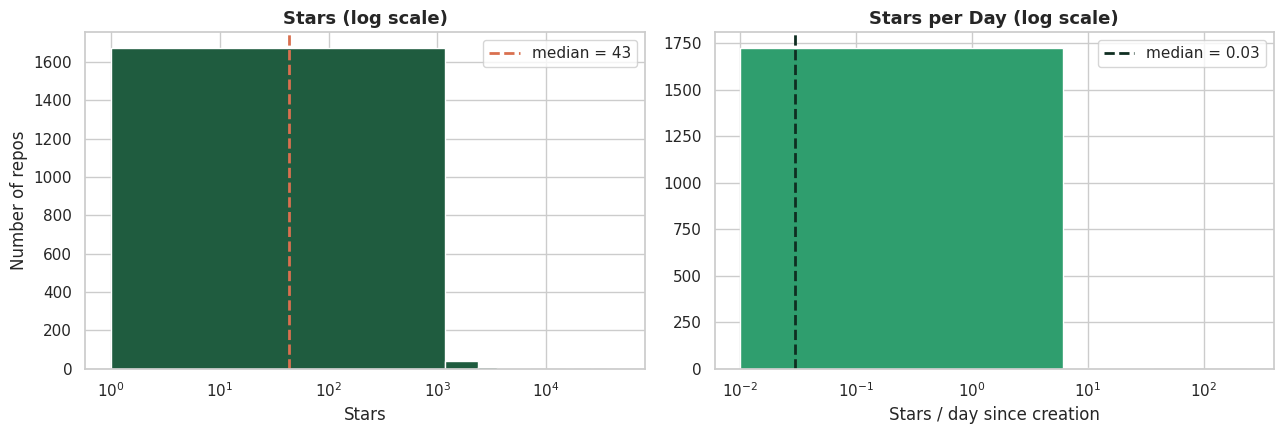

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['stars'].clip(lower=1), bins=40, color=MOSS, edgecolor='white')
axes[0].set_xscale('log')
axes[0].axvline(df['stars'].median(), color=CORAL, linestyle='--', linewidth=2,
                 label=f"median = {df['stars'].median():.0f}")
axes[0].set_title('Stars (log scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Number of repos')
axes[0].legend()

axes[1].hist(df['stars_per_day'].clip(lower=0.01), bins=40, color=EMERALD, edgecolor='white')
axes[1].set_xscale('log')
axes[1].axvline(df['stars_per_day'].median(), color=PINE, linestyle='--', linewidth=2,
                 label=f"median = {df['stars_per_day'].median():.2f}")
axes[1].set_title('Stars per Day (log scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Stars / day since creation')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Both metrics show the classic GitHub power-law shape: most repos cluster at the low end (the median repo has just <b>43 stars</b>) while a small handful &mdash; like the top-ranked <code>nanobot</code> at nearly 47,000 &mdash; stretch the distribution out for miles. The mean (280 stars) is <b>6.5&times;</b> the median for exactly this reason, which is why every comparison below leans on medians rather than means wherever the two would tell meaningfully different stories.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Organization vs. User Ownership</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The single largest gap found in this dataset: repos owned by an organization vs. an individual.</p>
</div>


In [7]:
owner_summary = df.groupby('owner_type')[['stars', 'stars_per_day', 'forks']].agg(['median', 'mean']).round(2)
owner_summary

stars         stars_per_day        forks        
             median    mean        median  mean median    mean
owner_type                                                    
Organization   89.0  684.89          0.05  0.99   22.0  160.38
User           34.0  159.15          0.02  0.20    7.0   58.94

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Organization-owned repos substantially outperform individually-owned ones: <b>684.9</b> mean stars versus <b>159.2</b> (a <b>4.3&times;</b> gap), and a similar gap in stars_per_day. This makes intuitive sense &mdash; an organization behind a repo often means more maintainers, more marketing reach, and more staying power than a single person's side project, even though the majority of repos in this dataset (<b>1,337 of 1,735</b>) are still individually owned.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Visualizing the Ownership Gap</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The same comparison as a bar chart, on a log scale given the underlying skew.</p>
</div>


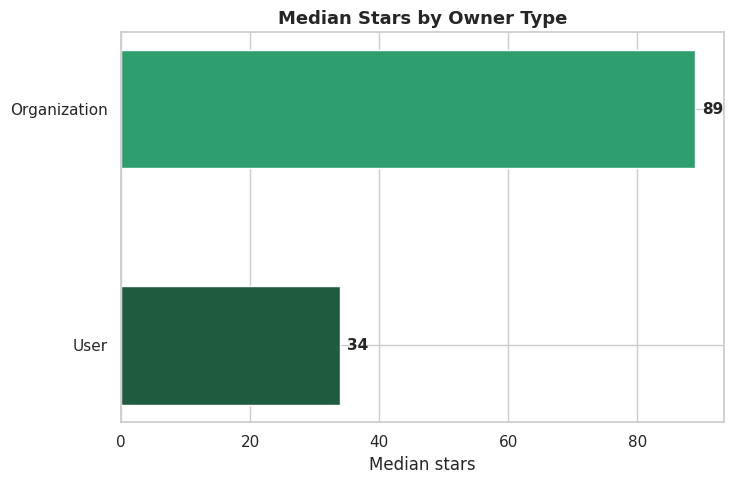

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5))
medians = df.groupby('owner_type')['stars'].median().sort_values()
ax.barh(medians.index, medians.values, color=[MOSS, EMERALD], edgecolor='white', height=0.5)
ax.set_xlabel('Median stars')
ax.set_title('Median Stars by Owner Type', fontsize=13, fontweight='bold')
for i, v in enumerate(medians.values):
    ax.text(v + 1, i, f'{v:.0f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The gap holds at the median too, not just the mean-skewing top end: organization-owned repos have a median of <b>89 stars</b> versus <b>34</b> for user-owned ones &mdash; roughly 2.6&times;, a smaller multiple than the 4.3&times; mean gap, but still a real and substantial difference. Ownership structure is a genuine, robust signal in this ecosystem &mdash; not just an artifact of a few huge outlier projects.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Official vs. Community Discord Repos</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">A more nuanced comparison: repos flagged as official Discord properties vs. everything else.</p>
</div>


In [9]:
official_summary = df.groupby('is_official_discord')[['stars', 'stars_per_day', 'repo_age_days']].agg(['median', 'mean']).round(2)
official_summary

stars         stars_per_day       repo_age_days         
                    median    mean        median  mean        median     mean
is_official_discord                                                          
False                 43.0  277.12          0.03  0.39        1865.0  1826.29
True                  60.5  329.02          0.03  0.14        2310.0  2248.20

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The picture here depends on which average you look at, which is itself worth flagging. At the <b>median</b>, official Discord repos (<b>88</b> of them, things like <code>discord-api-docs</code>) do have somewhat higher stars (60.5 vs 43.0) but <i>identical</i> stars_per_day (0.03 either way) &mdash; no momentum gap at all once outliers are set aside. At the <b>mean</b>, official repos show both higher stars (329 vs 277) <i>and</i> lower stars_per_day (0.14 vs 0.39), because a handful of extremely fast-growing community repos (like the chart-topping <code>nanobot</code>, at over 240 stars per day) pull the non-official mean up sharply. The honest takeaway: official status correlates with somewhat larger, older repos, but the "community repos are currently hotter" story only holds if you let a few outliers drive the comparison.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Correlation Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Scan the core popularity and activity metrics at once to spot the strongest relationships.</p>
</div>


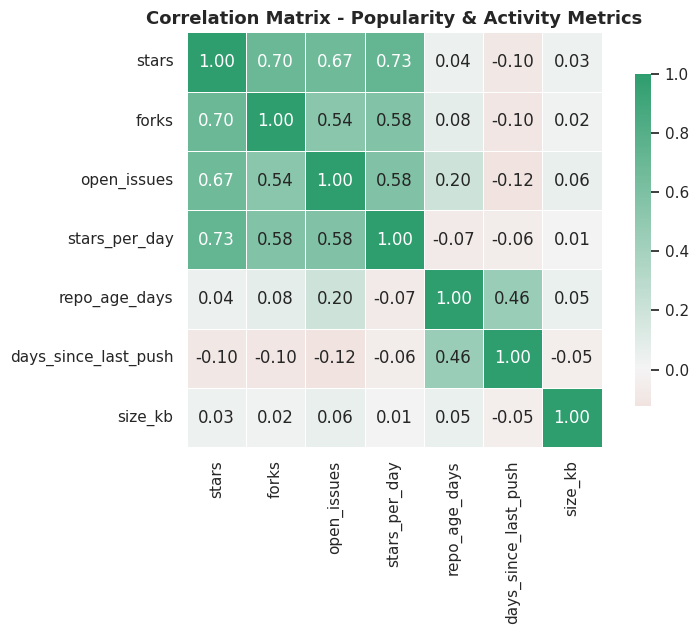

In [10]:
numeric_cols = ['stars', 'forks', 'open_issues', 'stars_per_day', 'repo_age_days', 'days_since_last_push', 'size_kb']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.blend_palette([CORAL, '#f4f4f4', EMERALD], as_cmap=True),
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Popularity & Activity Metrics', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>Stars</b> correlates most strongly with <b>forks</b> (0.70) and <b>stars_per_day</b> (0.73) &mdash; unsurprising, since more popular projects naturally attract more forks and were, definitionally, accumulating stars faster to get there. Two things worth calling out as genuine negative results rather than gaps in the analysis: <b>repo_age_days</b> barely correlates with <b>stars</b> (0.04) or <b>stars_per_day</b> (&minus;0.07) &mdash; older repos aren't systematically bigger or more (or less) actively starred than newer ones in this ecosystem. <b>size_kb</b> is essentially uncorrelated with everything, which tracks: codebase size on disk has little to do with a project's popularity.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Language Ecosystem</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Which languages this ecosystem is actually built in, and how repo size compares to popularity by language.</p>
</div>


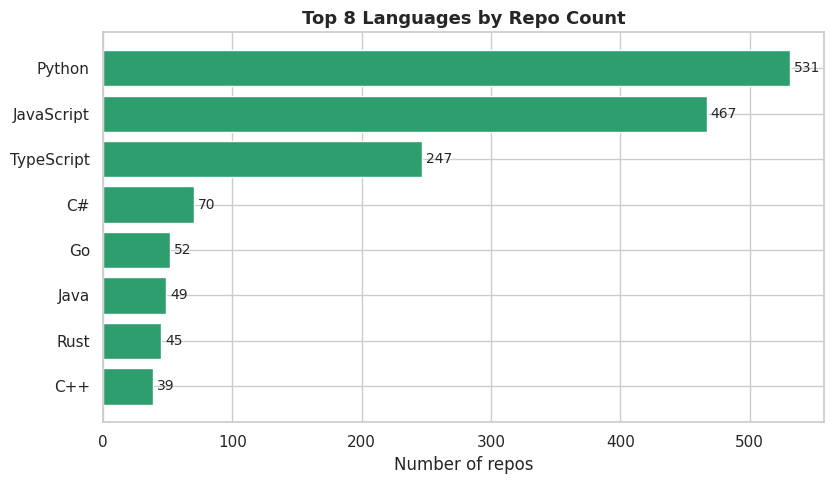

In [11]:
top_langs = df['language'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(top_langs.index[::-1], top_langs.values[::-1], color=EMERALD, edgecolor='white')
ax.set_xlabel('Number of repos')
ax.set_title('Top 8 Languages by Repo Count', fontsize=13, fontweight='bold')
for i, v in enumerate(top_langs.values[::-1]):
    ax.text(v + 3, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>Python</b> and <b>JavaScript</b> together account for roughly <b>60%</b> of the ecosystem (531 and 467 repos respectively), with <b>TypeScript</b> a clear third at 247. This lines up with what you'd expect from Discord bot development specifically: discord.py and discord.js are the two dominant wrapper libraries, and most bots built on top of them inherit their host language.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">The Ecosystem's Graveyard</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">How archived repos differ from active ones — and whether abandonment rates vary by language.</p>
</div>


In [12]:
archived_summary = df.groupby('archived')[['stars', 'stars_per_day', 'days_since_last_push']].median().round(1)
print(archived_summary)
print()

top8 = df['language'].value_counts().head(8).index
archived_by_lang = (df[df['language'].isin(top8)].groupby('language')['archived'].mean() * 100).sort_values(ascending=False)
archived_by_lang.round(1)

          stars  stars_per_day  days_since_last_push
archived                                            
False      42.0            0.0                 495.0
True       50.0            0.0                1348.0



language
Java          24.5
JavaScript    22.5
Go            21.2
Python        16.0
C#            15.7
TypeScript    14.2
C++           12.8
Rust          11.1
Name: archived, dtype: float64

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>17.1%</b> of repos in this dataset (297 of 1,735) are archived. As expected, archived repos have gone quiet for far longer &mdash; a median of <b>1,348 days</b> since the last push versus <b>495</b> for active repos, nearly 3&times; the gap. What's <i>not</i> what you might expect: archived repos have a slightly <b>higher</b> median star count (50 vs 42), not lower. Archiving on GitHub isn't always a synonym for failure &mdash; a project can reach a stable, "done" state and get archived deliberately after already accumulating real popularity, rather than being abandoned before it ever took off. Archive rates vary by language from <b>11.1%</b> (Rust) to <b>24.5%</b> (Java), but we'd be careful reading too much into that spread on its own: it likely reflects which era and which specific projects happened to adopt each language for Discord tooling, not something inherent to the languages themselves.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 45%, #2f9e6e 78%, #e3b23c 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Small Popularity Model</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Combining the strongest signals into a simple linear regression predicting log-stars.</p>
</div>


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df.dropna(subset=['forks', 'open_issues', 'repo_age_days']).copy()
model_df['is_org'] = (model_df['owner_type'] == 'Organization').astype(int)
model_df['log_stars'] = np.log1p(model_df['stars'])

features = ['forks', 'open_issues', 'repo_age_days', 'is_org']
X = model_df[features]
y = model_df['log_stars']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

y_pred = reg.predict(X_test_scaled)

print(f"R-squared: {r2_score(y_test, y_pred):.3f}")
print(f"MAE (log-stars): {mean_absolute_error(y_test, y_pred):.3f}")

coefs = pd.Series(reg.coef_, index=features).sort_values(key=abs, ascending=False)
coefs

R-squared: 0.303
MAE (log-stars): 1.258


open_issues      0.496764
repo_age_days    0.392582
forks            0.361952
is_org           0.186322
dtype: float64

<div style="
    border-left: 4px solid #d9704f;
    background: #fbf1ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2620;
">
<b style="color:#d9704f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A four-feature linear regression on log-transformed stars explains a modest share of the variance (<b>R&sup2; = 0.30</b>). The four standardized coefficients are fairly close to each other rather than one dominating: <b>open_issues</b> actually edges out <b>repo_age_days</b> and <b>forks</b> for the largest effect, which is a slightly different story than the correlation heatmap alone would suggest, since open_issues and forks were similarly correlated with stars there. <b>is_org</b> has the smallest coefficient of the four but is still clearly positive, meaning the ownership gap found earlier survives even after controlling for forks and issue count &mdash; it isn't fully explained away by organizations simply having more-forked, more-active repos. This is a proof-of-concept model meant to compare which signals matter relative to each other, not a tool for predicting any individual repo's future popularity.
</div>


<div style="
    background: linear-gradient(100deg, #0f2e21 0%, #1f5c3f 50%, #2f9e6e 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>Organization ownership is the clearest categorical signal</b> in this dataset: org-owned repos have roughly 4.3&times; the mean stars of user-owned ones, and the gap holds at the median too.</li>
<li><b>Official Discord status is nuanced</b>: official repos have higher stars at both the median and mean, but the "community repos have more momentum" story only holds if you use the mean, which a few extreme outliers (like the 240-stars-per-day <code>nanobot</code>) are driving &mdash; at the median, stars_per_day is identical between official and community repos.</li>
<li><b>stars and watchers are perfectly redundant</b> in this data (identical in every row), a known GitHub API quirk rather than a coincidence &mdash; reported here as found rather than silently worked around.</li>
<li><b>Repo age carries almost no signal</b> on its own: neither total stars nor stars_per_day meaningfully correlates with how long a repo has existed, a genuine negative result rather than a gap in the analysis.</li>
<li><b>Python and JavaScript dominate</b> the ecosystem (about 60% combined), tracking directly with discord.py and discord.js as the two most-used wrapper libraries.</li>
<li><b>Archived doesn't mean unpopular</b>: archived repos have gone quiet far longer than active ones (a median of 1,348 days since the last push vs. 495), but they actually have a slightly higher median star count &mdash; archiving a mature, already-popular project is common, not just abandoning a failed one.</li>
<li>This dataset reflects a snapshot of public GitHub metadata at one point in time; star counts, archive status, and activity timestamps will have moved on by the time this notebook is read, so treat specific figures as illustrative of relative patterns rather than a live picture of the ecosystem.</li>
</ul>
</div>
